# Demand Forecasting with Prophet (Weekly Optimization)

In our initial daily baseline, the error margins (MAPE) were likely very high. This is extremely common in retail data: daily sales are highly volatile due to random wholesale spikes, people shopping on different days, and weather events. 

**To drastically improve our forecasting accuracy, we will:**
1. **Resample to Weekly Revenue**: Predicting weekly revenue completely smooths out the random daily noise.
2. **Add Country Holidays**: We will explicitly tell Prophet to expect massive shifts around UK Holidays (like Christmas and Bank Holidays).

**Prophet** is a forecasting procedure developed by Facebook (Meta) designed for business time series data that has:
- Strong seasonal patterns (daily, weekly, yearly)
- Holiday effects
- Trend changes (changepoints)

In [ ]:
# Loading Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import mlflow

from prophet import Prophet
from prophet.serialize import model_to_json
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Data Preparation (Weekly Resampling)
We will aggregate our data into total sales per week.

In [43]:
# Transaction data
df = pd.read_csv('../data/processed/online_retail_initial.csv', usecols=['InvoiceDate', 'TotalPrice'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date

# 1. Daily Revenue
daily_revenue = df.groupby('Date')['TotalPrice'].sum().reset_index()
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])
daily_revenue.set_index('Date', inplace=True)

# 2. Resampling to WEEKLY Revenue to smooth massive volatility
weekly_revenue = daily_revenue.resample('W').sum().reset_index()

# Renaming columns to 'ds' and 'y' for Prophet
prophet_df = weekly_revenue.rename(columns={'Date': 'ds', 'TotalPrice': 'y'})

display(prophet_df.head())

,ds,y
0,2009-12-06,257747.44
1,2009-12-13,231195.04
2,2009-12-20,254975.12
3,2009-12-27,52730.90
4,2010-01-03,0.00


## 2. Train-Test Split (Last 12 Weeks)
We will hide the last 12 weeks (approx 3 months) to test our model.

In [44]:
forecast_horizon_weeks = 12 

# Split the data
train_df = prophet_df.iloc[:-forecast_horizon_weeks]
test_df = prophet_df.iloc[-forecast_horizon_weeks:]

print(f"Training Data: {len(train_df)} weeks (Ends on {train_df['ds'].max().date()})")
print(f"Testing Data : {len(test_df)} weeks (Ends on {test_df['ds'].max().date()})")

Training Data: 94 weeks (Ends on 2011-09-18)
Testing Data : 12 weeks (Ends on 2011-12-11)


## 3. Model Initialization & Training (With Holidays!)
We tell Prophet to use Yearly seasonality and automatically add UK holidays!

In [45]:
# Initialize Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
model.add_country_holidays(country_name='UK')

# Fit the model
model.fit(train_df)
print("Optimized Prophet model successfully trained!")

21:11:19 - cmdstanpy - INFO - Chain [1] start processing
21:11:20 - cmdstanpy - INFO - Chain [1] done processing


Optimized Prophet model successfully trained!


## 4. Forecasting the Future

In [46]:
# Future dataframe for the test period
future = model.make_future_dataframe(periods=forecast_horizon_weeks, freq='W')

# Forecast
forecast = model.predict(future)

# Comparison Dataframe
comparison = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[-forecast_horizon_weeks:]
comparison['actual'] = test_df['y'].values

display(comparison.head())

,ds,yhat,yhat_lower,yhat_upper,actual
94,2011-09-25,254567.144908,219793.806375,292413.088134,325679.011
95,2011-10-02,300583.095864,264910.496479,338798.984751,206568.851
96,2011-10-09,296190.053696,258268.469891,332727.790332,301565.420
97,2011-10-16,258198.143368,223121.952732,293646.005940,207345.610
98,2011-10-23,232744.807132,194243.778993,269946.366696,263103.750


## 5. Model Evaluation
Let's see if the errors are lower than the daily baseline.

In [47]:
actual = comparison['actual']
predicted = comparison['yhat']

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"--- Weekly Prophet Optimized Evaluation ---")
print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

--- Weekly Prophet Optimized Evaluation ---
Mean Absolute Error (MAE): £31,266.50
Root Mean Squared Error (RMSE): £41,389.71
Mean Absolute Percentage Error (MAPE): 11.98%


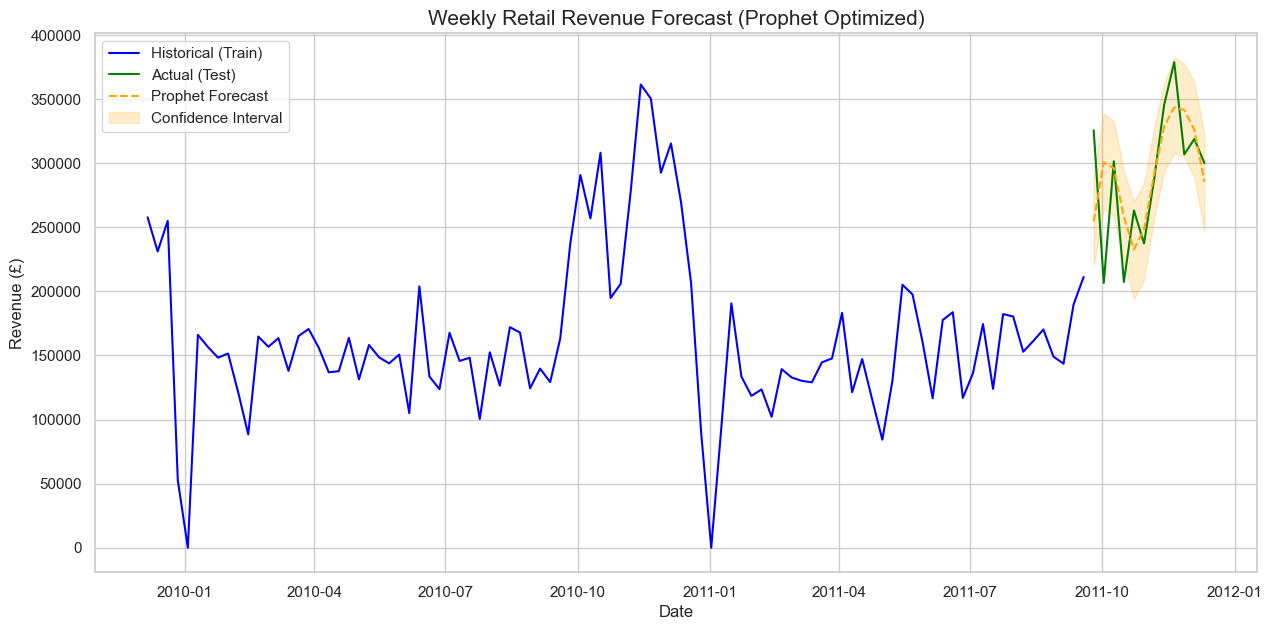

In [48]:
plt.figure(figsize=(15, 7))
plt.plot(train_df['ds'], train_df['y'], label='Historical (Train)', color='blue')
plt.plot(test_df['ds'], test_df['y'], label='Actual (Test)', color='green')
plt.plot(comparison['ds'], comparison['yhat'], label='Prophet Forecast', color='orange', linestyle='--')
plt.fill_between(comparison['ds'], comparison['yhat_lower'], comparison['yhat_upper'], color='orange', alpha=0.2, label='Confidence Interval')

plt.title("Weekly Retail Revenue Forecast (Prophet Optimized)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.legend()
plt.show()

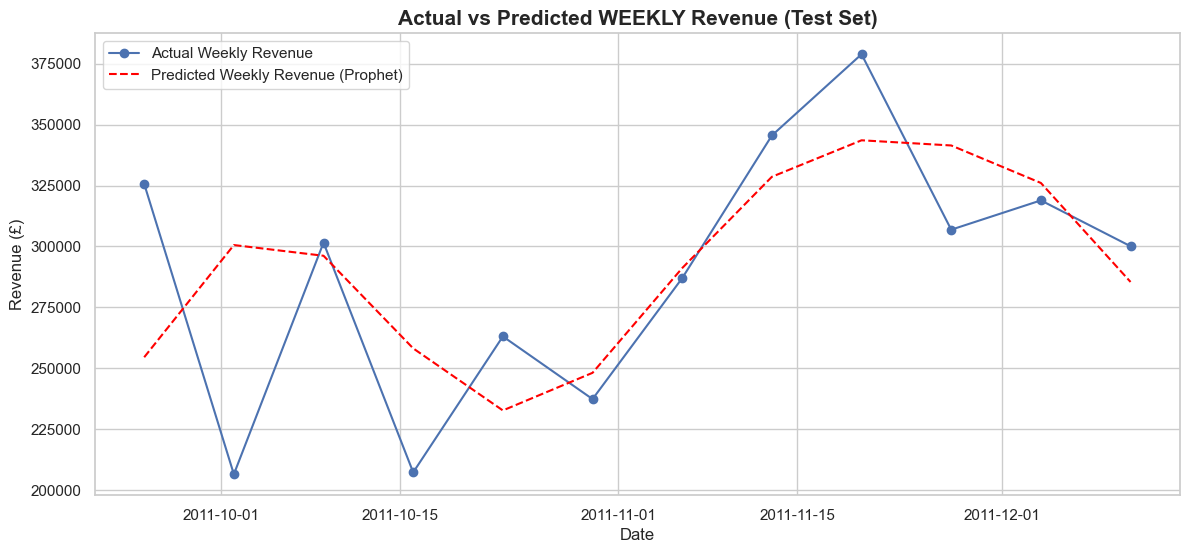

In [49]:
# Extract predicted dates matching Test Set
predictions = forecast.set_index('ds')[['yhat']].loc[test_df['ds']]
actuals = test_df.set_index('ds')['y']

# Plot Actuals vs Predictions closely
plt.figure(figsize=(14, 6))
plt.plot(actuals.index, actuals.values, label='Actual Weekly Revenue', marker='o')
plt.plot(predictions.index, predictions['yhat'].values, label='Predicted Weekly Revenue (Prophet)', color='red', linestyle='--')
plt.title('Actual vs Predicted WEEKLY Revenue (Test Set)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.show()

## 6. Model & Metrics Persistence
We save the standalone Prophet model and its performance metrics.

In [ ]:
os.makedirs('../models', exist_ok=True)

# Prophet Model
with open('../models/standalone_prophet_model.json', 'w') as f:
    f.write(model_to_json(model))

# Metrics
prophet_metrics = {
    'MAE': round(float(mae), 2),
    'RMSE': round(float(rmse), 2),
    'MAPE': round(float(mape), 2)
}

with open('../models/prophet_metrics.json', 'w') as f:
    json.dump(prophet_metrics, f, indent=4)

print("Success: Standalone Prophet model and metrics saved to '../models/'.")

Success: Standalone Prophet model and metrics saved to '../models/'.


In [51]:
# Local MLflow tracking
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("RetailPulse_Demand_Forecasting")

with mlflow.start_run(run_name="Prophet_Weekly_Baseline"):
    # Log parameters
    mlflow.log_param("forecast_horizon_weeks", forecast_horizon_weeks)
    mlflow.log_param("changepoint_prior_scale", 0.1)
    mlflow.log_param("holidays", "UK")
    
    # Log metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)

print("Prophet metrics successfully logged to MLflow!")

Prophet metrics successfully logged to MLflow!
